<a href="https://colab.research.google.com/github/princeiiitk/EDA_Netflix_Dataset/blob/main/EDA_Netflix_Content_Strategy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Project 2: In-Depth Exploratory Data Analysis (EDA)
Netflix Content Analysis 🎬
Project Objective: To perform an in-depth exploratory data analysis of the Netflix dataset. We will explore trends in content production, identify popular genres, analyze content ratings, and **understand** the distribution of movies and TV shows on the platform. This project builds on foundational EDA by introducing time-series analysis and more complex data cleaning and transformation techniques.

Core Concepts We'll Cover:
Data Cleaning & Transformation: Handling missing values and converting data types (especially dates).
Time-Series Analysis: Analyzing how content has been added to Netflix over the years.
Text Data Manipulation: Parsing and analyzing columns with multiple values, like listed_in (genres) and cast.
Geographical & Rating Analysis: Understanding where content comes from and its maturity level.
Feature Engineering: Creating new, insightful features like 'content age'.
Advanced Visualization: Creating insightful plots to understand distributions and relationships in the data.

Step 1: Setup-Importing Libraries

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style('darkgrid')

In [144]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"

fatal: destination path 'Datasets' already exists and is not an empty directory.


**Step 2 : Loading Dataset**

In [145]:
df=pd.read_csv('/content/Datasets/Netflix_Titles Dataset/netflix_titles.csv')

In [146]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


**Dataset information**
1.   Total number of row is 7787
2.   some of feature is less than 7787 that means some of value are missing like cast, director, country rating
3. formate of date and time is object(string) its must be Datetime



**Step 3: Data cleanign and Transformation**
This  step is necessary step in EDA process because this step we handle missing value and and convert correct formate of data                                                                                           1. Drop :if number of missing vlues is very
less or very small in percentage by the function of .dropna()                                                                                           2. fill/impute : Replace missing value with a placeholder(like unknown) or a statistical measure(like the mode for categorical daa) or by mean/mode

In [148]:
# 1. handle missing values in directorand cast
# since these are text field and many are missing we will fill them 'unknown'
df['director']=df['director'].fillna('unknown')
df['cast']=df['cast'].fillna('unknown')

In [149]:
# 2.Handle missing country
# we will fill with the mode which is most common country
country_count=df['country'].value_counts()
country_count
country_mode=df['country'].mode()
df['country']=df['country'].fillna(country_mode[0])


In [150]:
#3.Drop the some row those are missing means missing data s very less than we are directly drop the row like rating only 5-6 row are missing
df.dropna(subset=['rating','date_added'],inplace=True)

In [151]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7770 non-null   object
 1   type          7770 non-null   object
 2   title         7770 non-null   object
 3   director      7770 non-null   object
 4   cast          7770 non-null   object
 5   country       7770 non-null   object
 6   date_added    7770 non-null   object
 7   release_year  7770 non-null   int64 
 8   rating        7770 non-null   object
 9   duration      7770 non-null   object
 10  listed_in     7770 non-null   object
 11  description   7770 non-null   object
dtypes: int64(1), object(11)
memory usage: 789.1+ KB


In [152]:
df.shape

(7770, 12)

In [153]:
# 4. convert the formate of data and time currently in string formate
# used formate mixed
df['date_added']=pd.to_datetime(df['date_added'],format='mixed',dayfirst=False)


In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7770 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       7770 non-null   object        
 1   type          7770 non-null   object        
 2   title         7770 non-null   object        
 3   director      7770 non-null   object        
 4   cast          7770 non-null   object        
 5   country       7770 non-null   object        
 6   date_added    7770 non-null   datetime64[ns]
 7   release_year  7770 non-null   int64         
 8   rating        7770 non-null   object        
 9   duration      7770 non-null   object        
 10  listed_in     7770 non-null   object        
 11  description   7770 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 789.1+ KB


In [155]:
# 5. create new feature for year and months added
df['Year_added']=df['date_added'].dt.year
df['months_added']=df['date_added'].dt.month

In [156]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_added,months_added
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...,2020,10
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3
7784,s7785,Movie,Zulu Man in Japan,unknown,Nasty C,United States,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9
7785,s7786,TV Show,Zumbo's Just Desserts,unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,unknown,"United Kingdom, Canada, United States",2020-03-01,2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...,2020,3


In [157]:
# varify our cleaning and transformer
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [158]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,datetime64[ns]
release_year,int64
rating,object
duration,object


**Step 4 Exploratory data analysis and visualizaion **

What is the distribution of content type ?

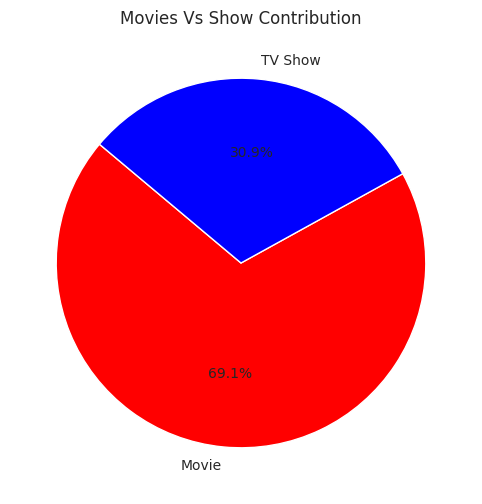

In [159]:
plt.figure(figsize=(8,6))
type_counts=df['type'].value_counts()
plt.pie(type_counts,labels=type_counts.index,autopct='%1.1f%%', startangle=140 ,colors=['red','blue'])
plt.title('Movies Vs Show Contribution')
plt.ylabel('')
plt.show()

Insights : In Dataset movie is more than show means movies is more contribution content than show

4.2 how has content been added over time

<Figure size 1400x800 with 0 Axes>

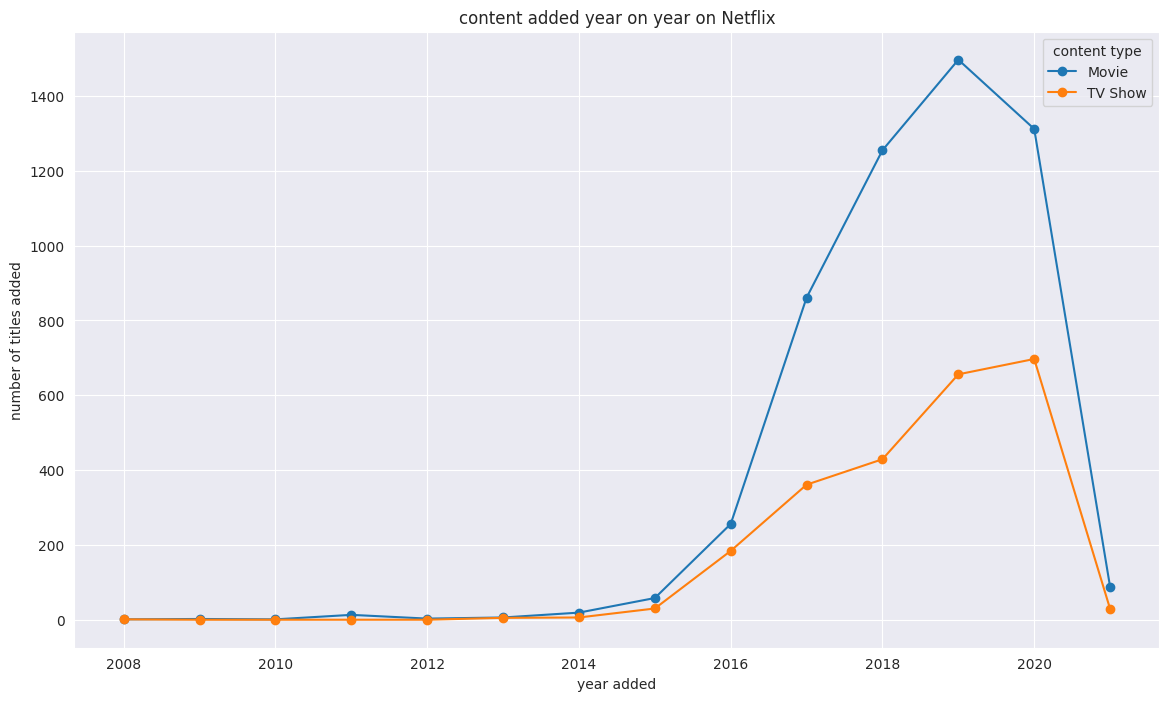

In [160]:
# Group data by year and content
content_over_time=df.groupby(['Year_added','type']).size().unstack().fillna(0)
plt.figure(figsize=(14,8))
content_over_time.plot(kind='line',marker='o',figsize=(14,8))
plt.title("content added year on year on Netflix")
plt.xlabel('year added')
plt.ylabel('number of titles added')
plt.legend(title='content type')
plt.grid(True)
plt.show()


Insights:
In year of 2019 to 2021 is peak time for movie and show add on netflix and 2020 to 2021 is covid period means in covid period people watching more movie and show

In [161]:
# splits the listed in column and explore it
df['genre']=df['listed_in'].str.split(', ').explode('genre')

In [162]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_added,months_added,genre
0,s1,TV Show,3%,unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,International TV Shows
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,TV Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12,TV Sci-Fi & Fantasy
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11,Dramas
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1,International Movies
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...",2020-10-19,2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...,2020,10,Thrillers
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2019,3,Children & Family Movies
7784,s7785,Movie,Zulu Man in Japan,unknown,Nasty C,United States,2020-09-25,2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast...",2020,9,Action & Adventure
7785,s7786,TV Show,Zumbo's Just Desserts,unknown,"Adriano Zumbo, Rachel Khoo",Australia,2020-10-31,2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...,2020,10,International Movies


In [163]:
#get the top 15 genre and thire counts
top_genres_counts=df['genre'].value_counts().reset_index()
# top_genres_counts
# select only 15
top_genres_counts=top_genres_counts.head(15)
top_genres_counts

,genre,count
0,International Movies,1142
1,Dramas,946
2,Comedies,660
3,International TV Shows,546
4,Documentaries,356
5,Action & Adventure,334
6,TV Dramas,313
7,Independent Movies,289
8,Children & Family Movies,249
9,Romantic Movies,244


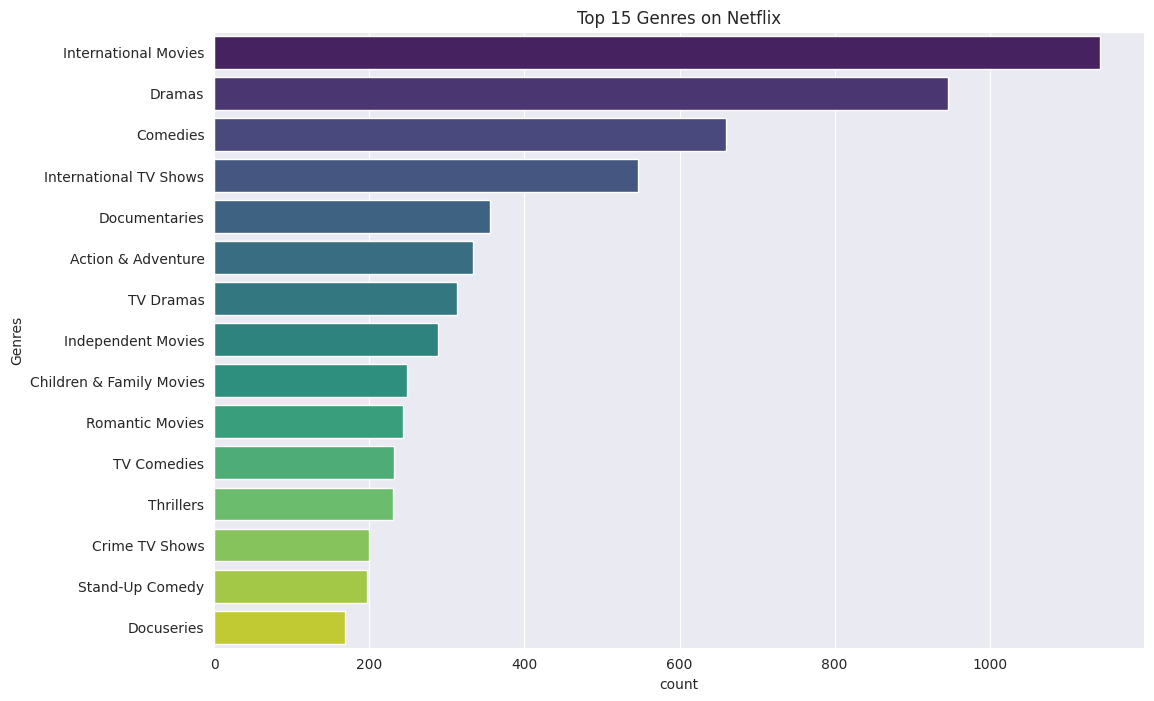

In [164]:
plt.figure(figsize=(12,8))
sns.barplot(y='genre',x='count',data=top_genres_counts,palette='viridis',hue='genre',legend=False)
plt.title('Top 15 Genres on Netflix')
plt.xlabel('count')
plt.ylabel('Genres')
plt.show()

**Insights International movie , drama ,a comedy movie is more on netflix**

4.4 What is the distribution of content duration?

In [165]:
#Seprate movies and TV show
movies_df=df[df['type']=='Movie'].copy()
show_df=df[df['type']=='TV Show'].copy()
# movies_df

In [166]:
# clean and convert duration for movies
movies_df['duration'] = movies_df['duration'].astype(str).str.replace(' min','').astype(int)

# clean and convert duration for tv show
show_df['duration'] = (
    show_df['duration']
    .astype(str)
    .str.replace(' Seasons?','', regex=True)
    .astype(int)
)




/tmp/ipykernel_1327/514832148.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1],data=show_df,x='duration',palette='viridis')


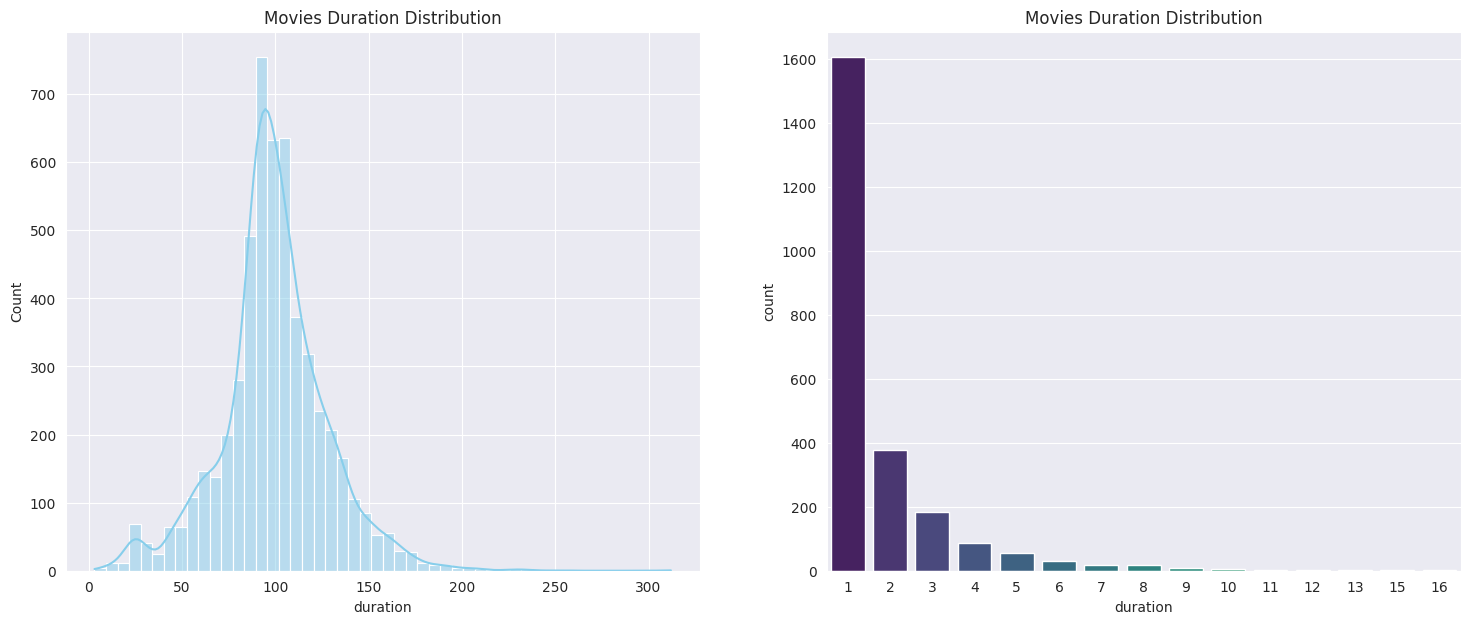

In [167]:
# plot distribution
fig, axes =plt.subplots(1,2,figsize=(18,7))
# movies duration distribution
sns.histplot(ax=axes[0],data=movies_df,x='duration',bins=50, kde=True,color='skyblue')
axes[0].set_title('Movies Duration Distribution')
sns.countplot(ax=axes[1],data=show_df,x='duration',palette='viridis')
axes[1].set_title('Movies Duration Distribution')
plt.show()



Insight maximum movies 100 min to 120 min long  and maximum tv show show season 1

4.5 Where does the content come from? (Geographical Analysis)

In [168]:
#handle the multi-country listing similar to genres
countries=df.assign(country=df['country'].str.split(' ,')).explode('country')

In [169]:
countries[0:2]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Year_added,months_added,genre
0,s1,TV Show,3%,unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8,International TV Shows
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12,TV Dramas


In [170]:
df.shape

(7770, 15)

In [171]:
#get top 15 country and their count
# df['country'].value_counts()
top_country_counts=countries['country'].value_counts().reset_index()
top_country_counts.columns=['country','counts']
top_country_counts=top_country_counts.head(15)



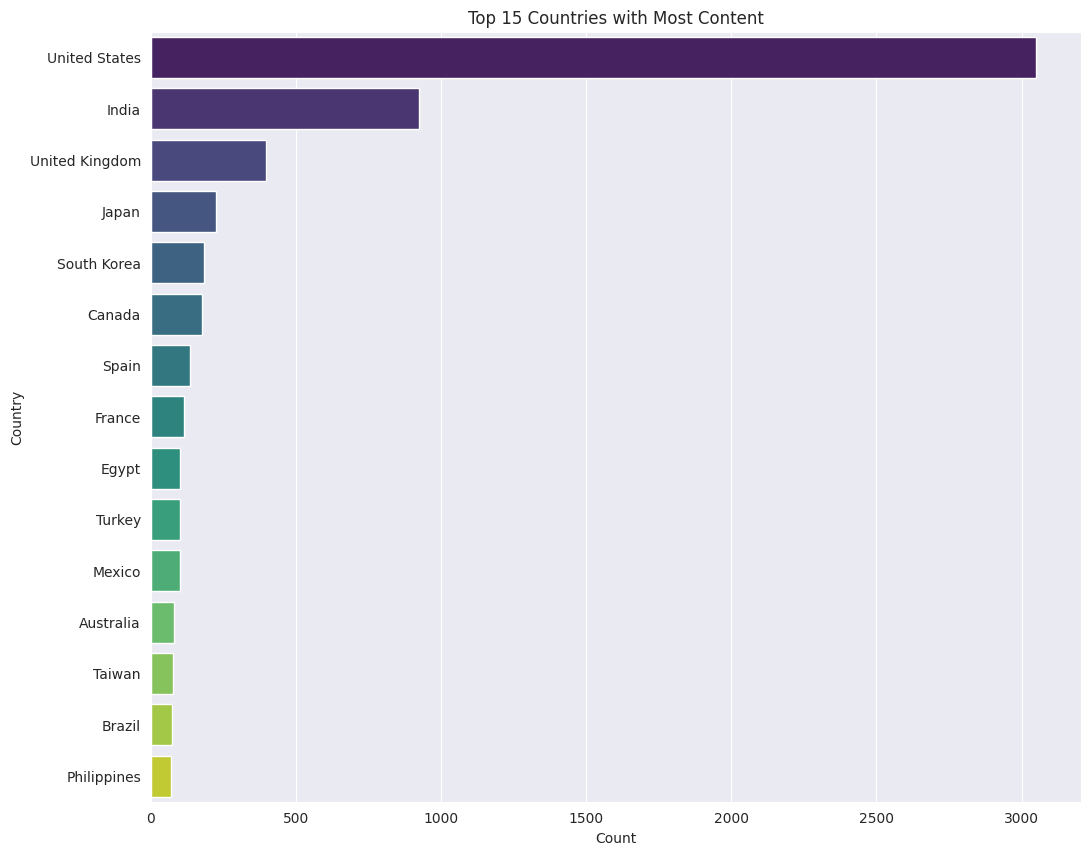

In [172]:
# select only the top 15 country for plotting
top_country_counts_plot=top_country_counts
plt.figure(figsize=(12,10))
sns.barplot(y='country',x='counts',data=top_country_counts_plot,palette='viridis',hue='country',legend=False)
plt.title('Top 15 Countries with Most Content')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()

Insight : most of movie from USA because we are added missing value by USA but before that also an USA and second most movies from our country India that means **USA and india is largest production** movies and tv show

4.6 What are the maturity ratings of the content?

In [173]:
df['rating'].value_counts()

,count
rating,
TV-MA,2861
TV-14,1928
TV-PG,804
R,665
PG-13,386
TV-Y,279
TV-Y7,270
PG,247
TV-G,194


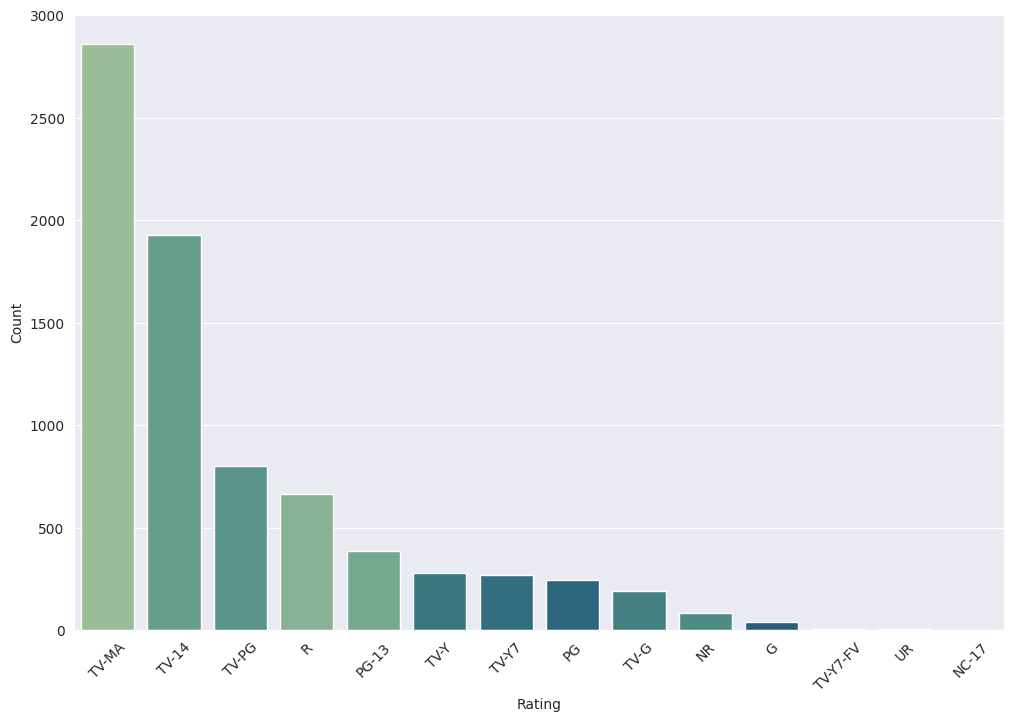

In [174]:
plt.figure(figsize=(12,8))
sns.countplot(x='rating',data=df,order=df['rating'].value_counts().index, palette='crest', hue='rating', legend=False)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


Insights : large number of audience belonging TV-MA (mature audience ) and TV-14 its most common rating

Step 5: Feature Engineering - Content Freshness
Let's create a new feature to analyze how old content is when it gets added to Netflix. This can tell us about their acquisition strategy (buying old classics vs. releasing new originals).

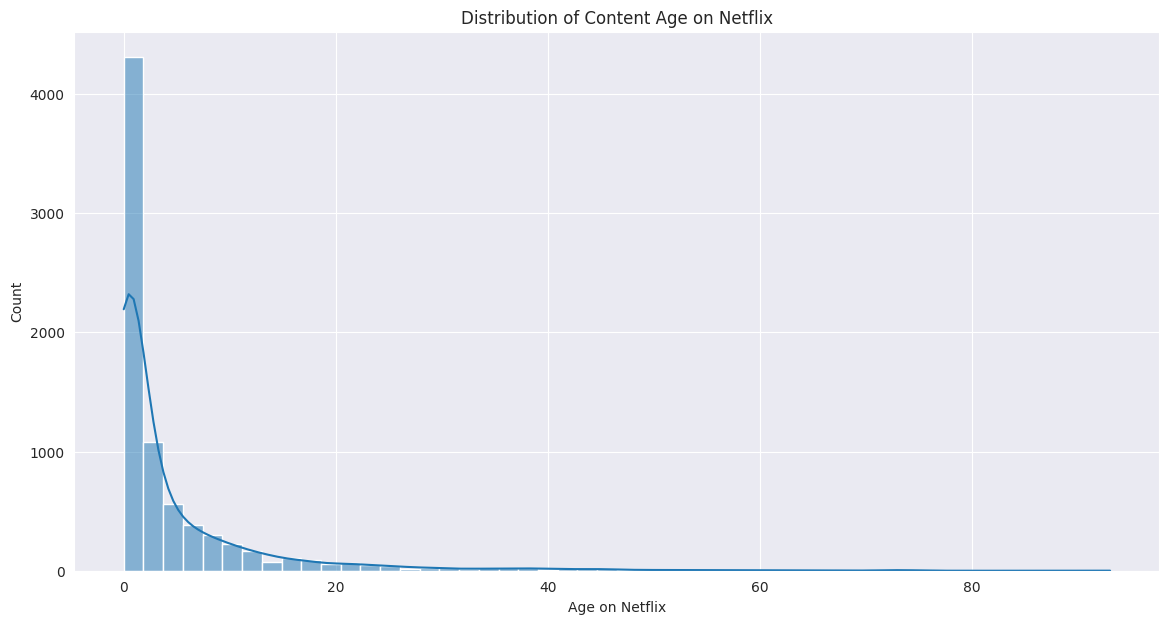

In [175]:
# create new feature is called 'age_on_netflix'
df['age_on_netflix']=df['Year_added']-df['release_year']
# df.shape
# Filter out any potential error where added_year is before release year\
content_age=df[df['age_on_netflix']>=0]
# content_age.shape

plt.figure(figsize=(14,7))
sns.histplot(x='age_on_netflix',data=content_age,bins=50,kde=True)
plt.title("Distribution of Content Age on Netflix")
plt.xlabel('Age on Netflix')
plt.ylabel('Count')
plt.show()

Insight : large spike at 0 indicates thats a **maximum number of content added or release on same year** that reprasents netflix added movies and tv show on same year not delayed

Step 6: Deeper Multivariate Analysis

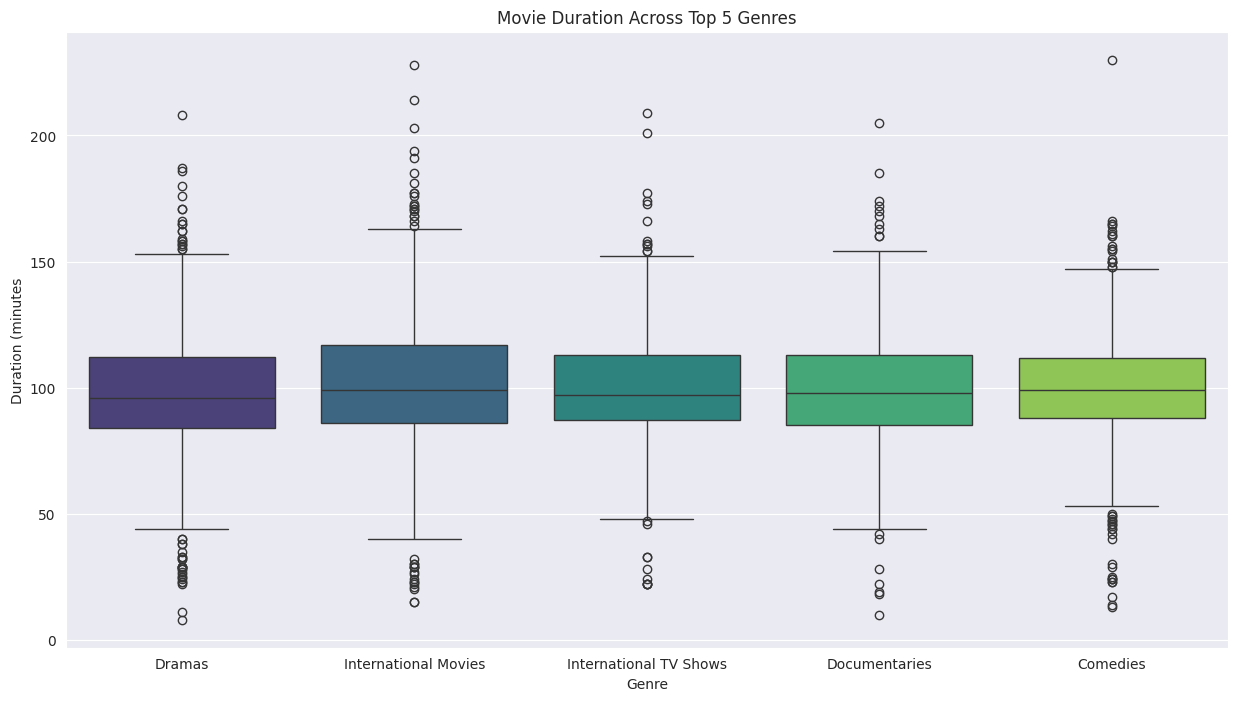

In [189]:
# Analyze movie duration across diff. top genres
# top
top5_genres=df['genre'].value_counts().index[:5]
top5_genres_movies=df[(df['type']=='Movie') & (df['genre'].isin(top5_genres))].copy()
top5_genres_movies['duration_min']=top5_genres_movies['duration'].str.replace(' min','').astype(int)
# top5_genresgenres_movies.head()

plt.figure(figsize=(15,8))
sns.boxplot(x='genre',y='duration_min',data=top5_genres_movies,palette='viridis',hue='genre',legend=False)

plt.xlabel('Genre')
plt.ylabel('Duration (minutes')
plt.title('Movie Duration Across Top 5 Genres')
plt.show()


Insight : while the median duration of movies is 90 to 100 min we can see interesting varition

Step 7: Word Cloud from Content Descriptions
As a final visual analysis, let's generate a word cloud from the description column to see what themes and words are most common in Netflix content.

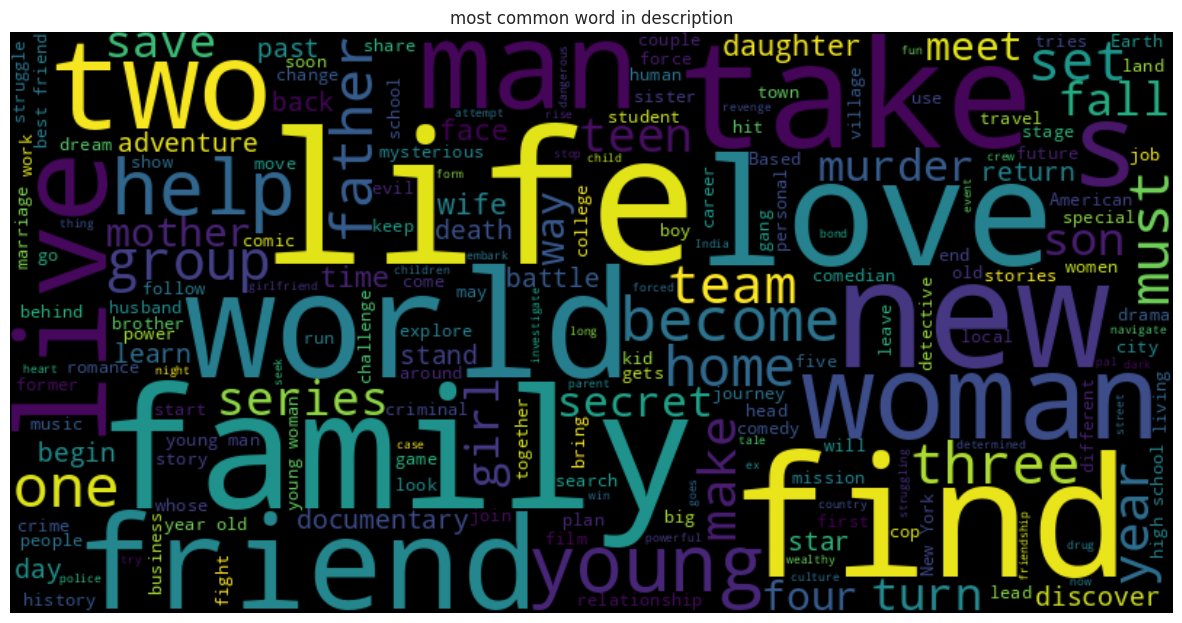

In [197]:
from wordcloud import WordCloud
text = ''.join(df['description'])
text
wordcloud =WordCloud(width=800, height=400 , background_color='black').generate(text);
plt.figure(figsize=(15,10))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('most common word in description')
plt.show()

Insight: The word cloud highlights common themes and subjects. Words like "life," "family," "love," "young," "friends," and "world" are prominent, suggesting that much of the content revolves around human relationships and personal journeys.

**How has the distribution of content ratings changed over time?**